## Activity 3

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(0)

In [5]:
data = pd.read_csv("datasets\Wholesale customers data.csv")

In [6]:
data.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

In [7]:
data.shape[1]

8

In [8]:
outliers = {}
for i in range(data.shape[1]):
    min_t = data[data.columns[i]].mean() - (3 * data[data.columns[i]].std())
    max_t = data[data.columns[i]].mean() + (3 * data[data.columns[i]].std())
    count = 0
    for j in data[data.columns[i]]:
        if j < min_t or j > max_t:
            count += 1
    outliers[data.columns[i]] = [count,data.shape[0]-count]
print(outliers)

{'Channel': [0, 440], 'Region': [0, 440], 'Fresh': [7, 433], 'Milk': [9, 431], 'Grocery': [7, 433], 'Frozen': [6, 434], 'Detergents_Paper': [10, 430], 'Delicassen': [4, 436]}


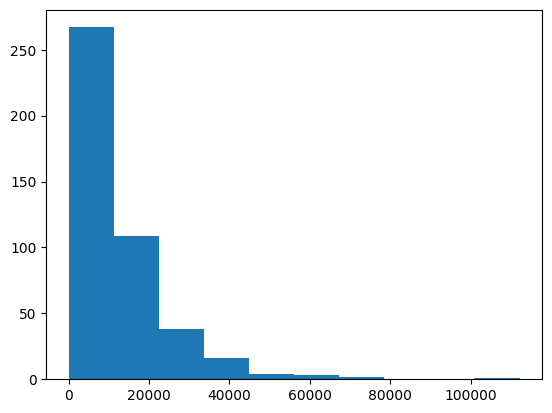

In [9]:
plt.hist(data["Fresh"])
plt.show()

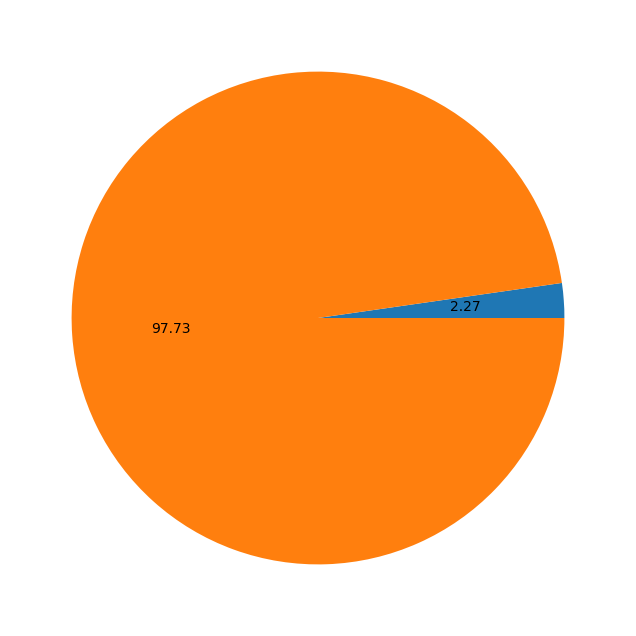

In [10]:
plt.figure(figsize=(8,8))
plt.pie(outliers["Detergents_Paper"],autopct="%.2f")
plt.show()

In [11]:
data_standardized = (data - data.mean())/data.std()
data_standardized.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,1.447005,0.589997,0.052873,0.522972,-0.041068,-0.588697,-0.043519,-0.066264
1,1.447005,0.589997,-0.390857,0.543839,0.170125,-0.269829,0.086309,0.089050
2,1.447005,0.589997,-0.446521,0.408073,-0.028125,-0.137379,0.133080,2.240742
3,-0.689512,0.589997,0.099998,-0.623310,-0.392530,0.686363,-0.498021,0.093305
4,1.447005,0.589997,0.839284,-0.052337,-0.079266,0.173661,-0.231654,1.297870


## Activity 4

In [12]:
from sklearn.cluster import KMeans

In [13]:
ideal_k = []
for i in range(1,21):
    est_kmeans = KMeans(n_clusters=i)
    est_kmeans.fit(data_standardized)
    
    ideal_k.append([i,est_kmeans.inertia_])

In [14]:
ideal_k = np.array(ideal_k)

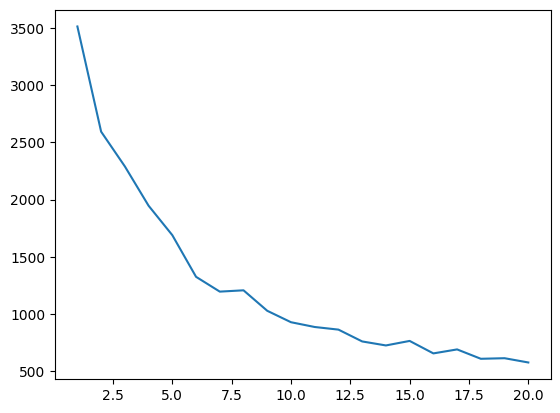

In [15]:
plt.plot(ideal_k[:,0],ideal_k[:,1])
plt.show()

A number of 6 cluster was selected

In [16]:
est_kmeans = KMeans(n_clusters=6)
est_kmeans.fit(data_standardized)
pred_kmeans = est_kmeans.predict(data_standardized)

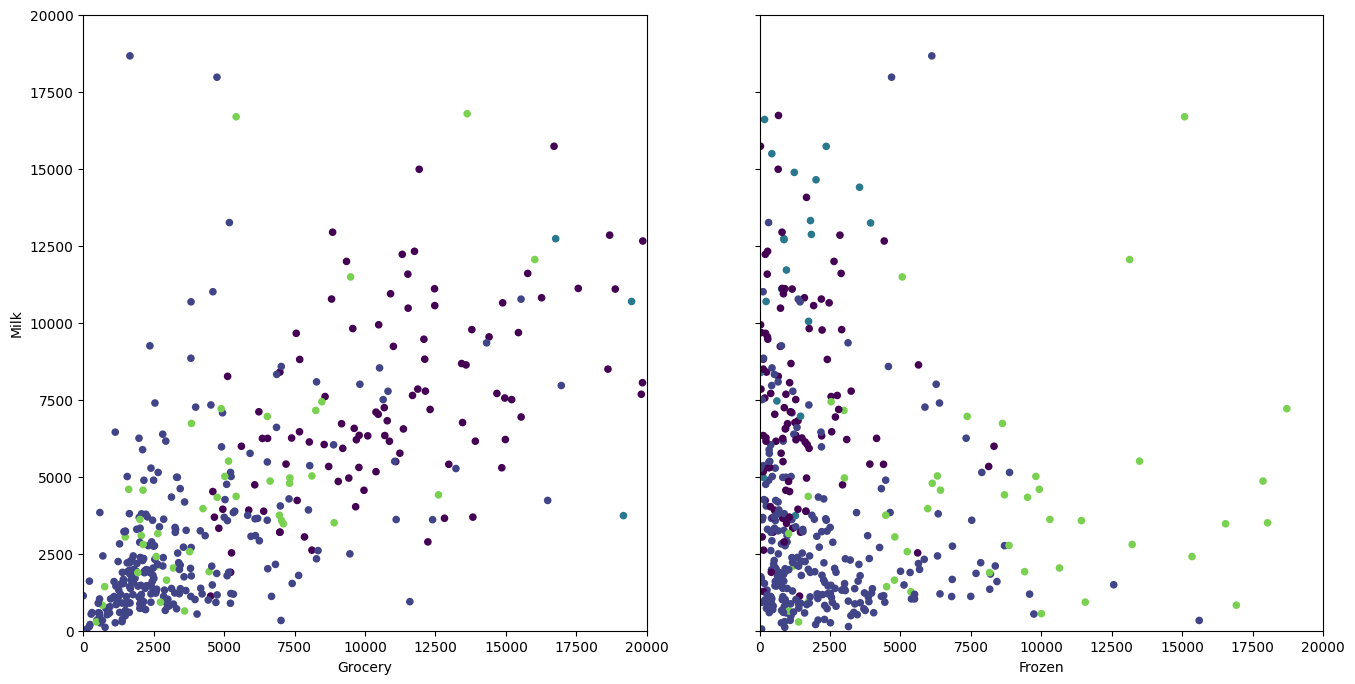

In [17]:
plt.subplots(1, 2, sharex='col', sharey='row', figsize=(16,8))
plt.scatter(data.iloc[:,5], data.iloc[:,3], c=pred_kmeans, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Frozen')
plt.subplot(1, 2, 1)
plt.scatter(data.iloc[:,4], data.iloc[:,3], c=pred_kmeans, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.show()

## Activity 5

In [18]:
from sklearn.cluster import MeanShift

In [19]:
bandwidth = 0.4
est_meanshift = MeanShift(bandwidth=bandwidth)
est_meanshift.fit(data_standardized)
pred_meanshift = est_meanshift.predict(data_standardized)

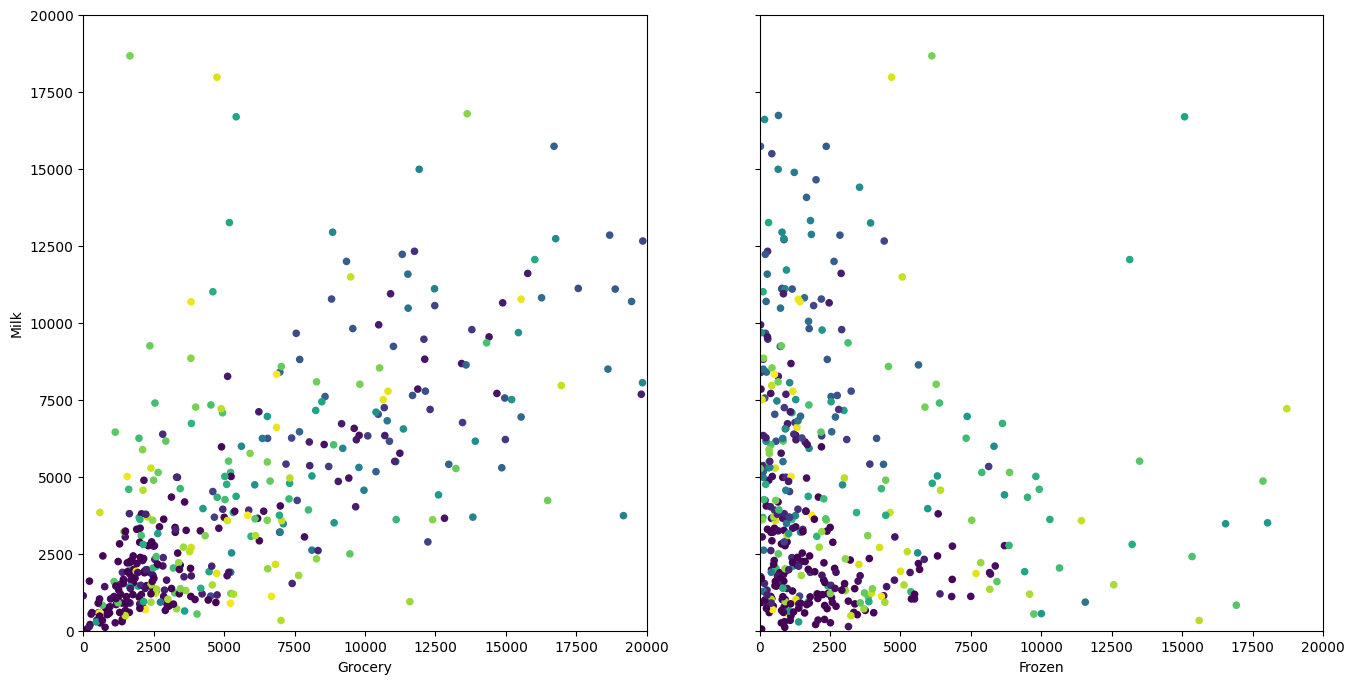

In [20]:
plt.subplots(1, 2, sharex='col', sharey='row', figsize=(16,8))
plt.scatter(data.iloc[:,5], data.iloc[:,3], c=pred_meanshift, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Frozen')
plt.subplot(1, 2, 1)
plt.scatter(data.iloc[:,4], data.iloc[:,3], c=pred_meanshift, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.show()

## Activity 6

In [21]:
from sklearn.cluster import DBSCAN

In [22]:
est_dbscan = DBSCAN(eps=0.8)
pred_dbscan = est_dbscan.fit_predict(data_standardized)

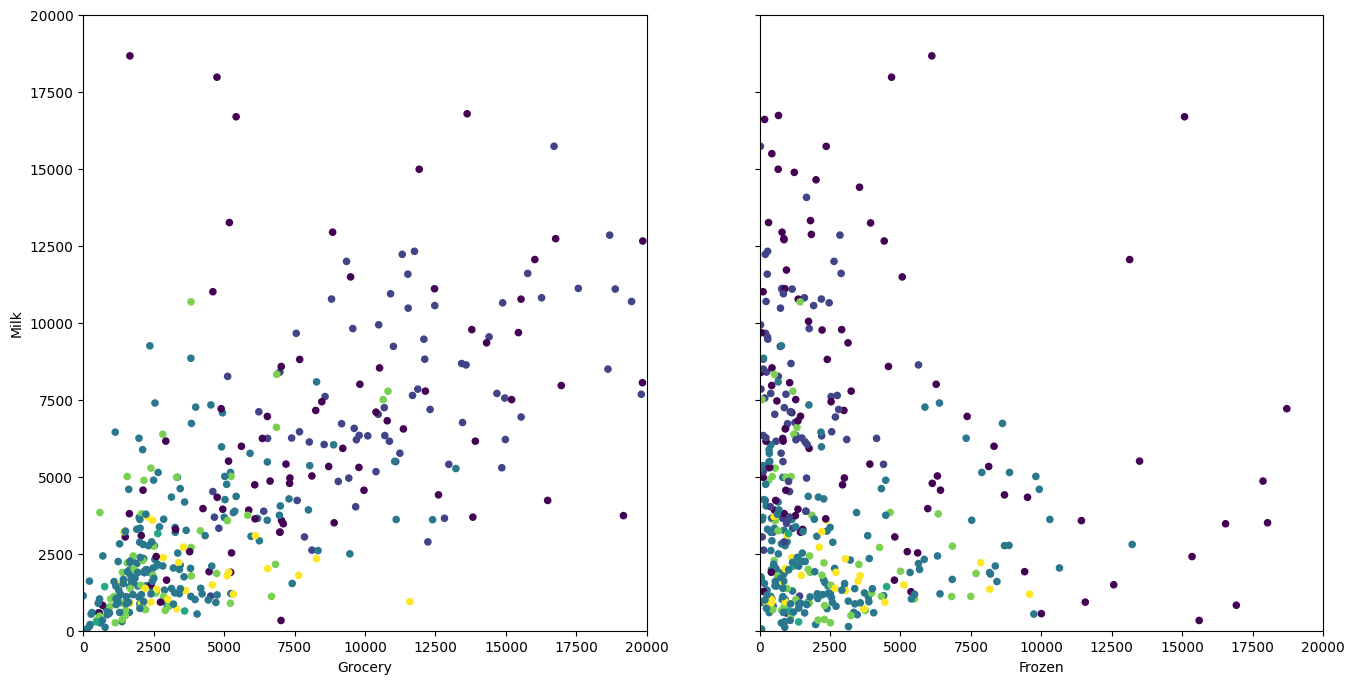

In [23]:
plt.subplots(1, 2, sharex='col', sharey='row', figsize=(16,8))
plt.scatter(data.iloc[:,5], data.iloc[:,3], c=pred_dbscan, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Frozen')
plt.subplot(1, 2, 1)
plt.scatter(data.iloc[:,4], data.iloc[:,3], c=pred_dbscan, s=20)
plt.xlim([0, 20000])
plt.ylim([0,20000])
plt.xlabel('Grocery')
plt.ylabel('Milk')
plt.show()

## Activity 7

In [24]:
from sklearn.metrics import silhouette_score

In [25]:
kmeans_score = silhouette_score(data_standardized, pred_kmeans, metric='euclidean')
meanshift_score = silhouette_score(data_standardized, pred_meanshift, metric='euclidean')
dbscan_score = silhouette_score(data_standardized, pred_dbscan, metric='euclidean')
print(kmeans_score, meanshift_score, dbscan_score)

0.3387247884541752 0.09334580346864553 0.16856375605964766


In [27]:
from sklearn.metrics import calinski_harabasz_score

In [28]:
kmeans_score = calinski_harabasz_score(data_standardized, pred_kmeans)
meanshift_score = calinski_harabasz_score(data_standardized, pred_meanshift)
dbscan_score = calinski_harabasz_score(data_standardized, pred_dbscan)
print(kmeans_score, meanshift_score, dbscan_score)

122.40700216922787 112.90534400805596 42.45114955569689
